Target: **1-day-ahead quantity forecast per Outlet × SKU**

Model:
- Lag-7
- Rolling Mean-7
- SBA
- TSB
- XGBoost
- XGBoost Tweedie
- Hard Hurdle XGBoost
- Occurrence-Aware Tweedie

Metrik utama: **MASE, MAE, RMSE, Exact Accuracy, Within ±1 Accuracy, Bias**

In [3]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

SEED = 42
TARGET = "QuantitySold"

TRANSACTIONS_PATH = "../data/raw/Transactions.csv"
PRODUCTS_PATH = "../data/raw/Products.csv"
CORE_SKU_PATH = "../data/processed/core_15_skus.csv"

## 1. Load dan siapkan data

In [4]:
transactions = pd.read_csv(TRANSACTIONS_PATH)
products = pd.read_csv(PRODUCTS_PATH)

transactions["Date"] = pd.to_datetime(transactions["Date"])
products["ProductId"] = products["ProductId"].astype(str)

products["ItemName"] = products.apply(
    lambda row: row["ProductName"]
    if row["Variant"] == "-"
    else f'{row["ProductName"]} ({row["Variant"]})',
    axis=1
)

items_df = transactions.copy()
items_df["ItemName"] = items_df["Items"].str.split(",")
items_df = items_df.explode("ItemName")
items_df["ItemName"] = items_df["ItemName"].str.strip()

items_merged = items_df.merge(
    products[
        ["ProductId", "ProductName", "Variant", "Category", "Price", "ItemName"]
    ],
    on="ItemName",
    how="left",
    validate="many_to_one"
)

assert items_merged["ProductId"].isna().sum() == 0

items_merged["Quantity"] = 1
items_merged["Outlet"] = items_merged["Outlet"].astype(str)
items_merged["ProductId"] = items_merged["ProductId"].astype(str)

daily_sales = (
    items_merged
    .groupby(
        ["Date", "Outlet", "ProductId", "ProductName", "Variant", "Category"],
        as_index=False
    )
    .agg(QuantitySold=("Quantity", "sum"))
)

print("Products:", daily_sales["ProductId"].nunique())
print("Outlets :", daily_sales["Outlet"].nunique())

Products: 94
Outlets : 3


In [5]:
MIN_HISTORY_DAYS = 60
MIN_POSITIVE_DAYS = 10

dataset_end = daily_sales["Date"].max()

eligibility = (
    daily_sales
    .groupby(["Outlet", "ProductId"])
    .agg(
        FirstSale=("Date", "min"),
        PositiveDays=("Date", "nunique"),
    )
    .reset_index()
)

eligibility["HistoryDays"] = (
    dataset_end - eligibility["FirstSale"]
).dt.days + 1

eligible_pairs = eligibility[
    (eligibility["HistoryDays"] >= MIN_HISTORY_DAYS) &
    (eligibility["PositiveDays"] >= MIN_POSITIVE_DAYS)
][["Outlet", "ProductId", "FirstSale"]].copy()

print("Eligible series  :", len(eligible_pairs))
print("Eligible products:", eligible_pairs["ProductId"].nunique())

Eligible series  : 282
Eligible products: 94


In [6]:
panel_parts = []

for _, row in eligible_pairs.iterrows():
    temp = pd.DataFrame({
        "Date": pd.date_range(row["FirstSale"], dataset_end, freq="D"),
        "Outlet": row["Outlet"],
        "ProductId": row["ProductId"],
    })

    actual = daily_sales[
        (daily_sales["Outlet"] == row["Outlet"]) &
        (daily_sales["ProductId"] == row["ProductId"])
    ][["Date", TARGET]]

    temp = temp.merge(actual, on="Date", how="left")
    temp[TARGET] = temp[TARGET].fillna(0).astype(int)
    panel_parts.append(temp)

panel = pd.concat(panel_parts, ignore_index=True)
panel = panel.sort_values(["Outlet", "ProductId", "Date"]).reset_index(drop=True)

panel = panel.merge(
    products[["ProductId", "ProductName", "Variant", "Category"]],
    on="ProductId",
    how="left"
)

g = panel.groupby(["Outlet", "ProductId"])[TARGET]

for lag in [1, 2, 3, 7, 14]:
    panel[f"lag_{lag}"] = g.shift(lag)

panel["rolling_mean_7"] = g.transform(
    lambda s: s.shift(1).rolling(7, min_periods=1).mean()
)
panel["rolling_mean_14"] = g.transform(
    lambda s: s.shift(1).rolling(14, min_periods=1).mean()
)
panel["rolling_sum_7"] = g.transform(
    lambda s: s.shift(1).rolling(7, min_periods=1).sum()
)
panel["zero_days_7"] = g.transform(
    lambda s: s.shift(1).eq(0).rolling(7, min_periods=1).sum()
)

panel["day_of_week"] = panel["Date"].dt.dayofweek
panel["day_of_month"] = panel["Date"].dt.day
panel["month"] = panel["Date"].dt.month
panel["is_weekend"] = panel["day_of_week"].isin([5, 6]).astype(int)

model_df = panel.dropna(subset=["lag_14"]).copy().reset_index(drop=True)

print("Model rows :", len(model_df))
print("Zero rate  :", round(model_df[TARGET].eq(0).mean() * 100, 2), "%")

Model rows : 72487
Zero rate  : 46.62 %


## 2. Temporal validation dan metrik

In [7]:
FOLDS = [
    {"fold": 1, "train_end": "2025-06-30", "valid_start": "2025-07-01", "valid_end": "2025-07-31"},
    {"fold": 2, "train_end": "2025-07-31", "valid_start": "2025-08-01", "valid_end": "2025-08-31"},
    {"fold": 3, "train_end": "2025-08-31", "valid_start": "2025-09-01", "valid_end": "2025-09-30"},
]

def split_fold(data, fold):
    train = data[data["Date"] <= pd.Timestamp(fold["train_end"])].copy()
    valid = data[
        (data["Date"] >= pd.Timestamp(fold["valid_start"])) &
        (data["Date"] <= pd.Timestamp(fold["valid_end"]))
    ].copy()
    return train, valid

def panel_mase(train_df, valid_df, predictions):
    temp = valid_df.copy()
    temp["_pred"] = np.asarray(predictions)
    scores = []

    for (outlet, product), valid_group in temp.groupby(["Outlet", "ProductId"]):
        history = train_df[
            (train_df["Outlet"] == outlet) &
            (train_df["ProductId"] == product)
        ].sort_values("Date")[TARGET].to_numpy(float)

        if len(history) < 2:
            continue

        scale = np.mean(np.abs(np.diff(history)))
        if scale <= 0:
            continue

        error = np.mean(
            np.abs(
                valid_group[TARGET].to_numpy(float) -
                valid_group["_pred"].to_numpy(float)
            )
        )
        scores.append(error / scale)

    return np.mean(scores)

def evaluate(name, fold_no, train, valid, predictions):
    y_true = valid[TARGET].to_numpy(int)
    y_pred = np.rint(np.clip(predictions, 0, None)).astype(int)

    return {
        "Model": name,
        "Fold": fold_no,
        "MASE": panel_mase(train, valid, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "ExactAccuracy": np.mean(y_true == y_pred),
        "Within1Accuracy": np.mean(np.abs(y_true - y_pred) <= 1),
        "Bias": np.mean(y_pred - y_true),
    }

def summarize(results):
    out = (
        results.groupby("Model")
        .agg(
            MASE_mean=("MASE", "mean"),
            MASE_std=("MASE", "std"),
            MAE_mean=("MAE", "mean"),
            RMSE_mean=("RMSE", "mean"),
            ExactAccuracy_mean=("ExactAccuracy", "mean"),
            Within1Accuracy_mean=("Within1Accuracy", "mean"),
            Bias_mean=("Bias", "mean"),
        )
        .reset_index()
    )

    out["AbsBias"] = out["Bias_mean"].abs()

    return out.sort_values(
        ["MASE_mean", "ExactAccuracy_mean", "Within1Accuracy_mean", "AbsBias"],
        ascending=[True, False, False, True],
    ).reset_index(drop=True)

## 3. Percobaan model

In [8]:
lag7_rows = []

for fold in FOLDS:
    train, valid = split_fold(model_df, fold)
    lag7_rows.append(
        evaluate(
            "Lag-7",
            fold["fold"],
            train,
            valid,
            valid["lag_7"].to_numpy(),
        )
    )

lag7_results = pd.DataFrame(lag7_rows)

In [9]:
def build_sba_state(history, alpha):
    y = np.asarray(history, float)
    nz = np.where(y > 0)[0]

    if len(nz) == 0:
        return None

    z = y[nz[0]]
    p = 1.0
    last = nz[0]

    for i in nz[1:]:
        z += alpha * (y[i] - z)
        p += alpha * ((i - last) - p)
        last = i

    return {"z": z, "p": p, "periods_since": max(len(y) - last, 1)}

def sba_forecast(state, alpha):
    if state is None:
        return 0.0
    return max(0.0, (1 - alpha / 2) * state["z"] / state["p"])

def update_sba(state, actual, alpha):
    if state is None:
        return {"z": actual, "p": 1.0, "periods_since": 1} if actual > 0 else None

    if actual > 0:
        interval = max(state["periods_since"], 1)
        state["z"] += alpha * (actual - state["z"])
        state["p"] += alpha * (interval - state["p"])
        state["periods_since"] = 1
    else:
        state["periods_since"] += 1

    return state

def predict_sba(full_df, valid_df, alpha):
    preds = pd.Series(index=valid_df.index, dtype=float)

    for (outlet, product), group in valid_df.groupby(["Outlet", "ProductId"]):
        group = group.sort_values("Date")
        start = group["Date"].min()

        history = full_df[
            (full_df["Outlet"] == outlet) &
            (full_df["ProductId"] == product) &
            (full_df["Date"] < start)
        ].sort_values("Date")[TARGET].to_numpy()

        state = build_sba_state(history, alpha)

        for idx, row in group.iterrows():
            preds.loc[idx] = sba_forecast(state, alpha)
            state = update_sba(state, row[TARGET], alpha)

    return preds.loc[valid_df.index].to_numpy()

SBA_ALPHAS = [0.05, 0.10, 0.15, 0.20]
sba_all = []

for alpha in SBA_ALPHAS:
    for fold in FOLDS:
        train, valid = split_fold(model_df, fold)
        row = evaluate(
            "SBA",
            fold["fold"],
            train,
            valid,
            predict_sba(model_df, valid, alpha),
        )
        row["Alpha"] = alpha
        sba_all.append(row)

sba_all = pd.DataFrame(sba_all)

sba_tuning = (
    sba_all.groupby("Alpha")
    .agg(MASE=("MASE", "mean"), MAE=("MAE", "mean"))
    .reset_index()
    .sort_values(["MASE", "MAE"])
)

BEST_SBA_ALPHA = float(sba_tuning.iloc[0]["Alpha"])
sba_results = sba_all[sba_all["Alpha"] == BEST_SBA_ALPHA].copy()

print("Best SBA alpha:", BEST_SBA_ALPHA)

Best SBA alpha: 0.2


In [10]:
def build_tsb_state(history, alpha, beta):
    y = np.asarray(history, float)
    nz = np.where(y > 0)[0]

    if len(nz) == 0:
        return None

    z = y[nz[0]]
    p = 1.0

    for value in y[nz[0] + 1:]:
        occurrence = float(value > 0)
        p += beta * (occurrence - p)
        if value > 0:
            z += alpha * (value - z)

    return {"z": z, "p": p}

def predict_tsb(full_df, valid_df, alpha, beta):
    preds = pd.Series(index=valid_df.index, dtype=float)

    for (outlet, product), group in valid_df.groupby(["Outlet", "ProductId"]):
        group = group.sort_values("Date")
        start = group["Date"].min()

        history = full_df[
            (full_df["Outlet"] == outlet) &
            (full_df["ProductId"] == product) &
            (full_df["Date"] < start)
        ].sort_values("Date")[TARGET].to_numpy()

        state = build_tsb_state(history, alpha, beta)

        for idx, row in group.iterrows():
            preds.loc[idx] = 0.0 if state is None else state["p"] * state["z"]

            actual = row[TARGET]

            if state is None:
                state = {"z": actual, "p": 1.0} if actual > 0 else None
            else:
                occurrence = float(actual > 0)
                state["p"] += beta * (occurrence - state["p"])
                if actual > 0:
                    state["z"] += alpha * (actual - state["z"])

    return preds.loc[valid_df.index].to_numpy()

TSB_GRID = [0.05, 0.10, 0.20]
tsb_all = []

for alpha in TSB_GRID:
    for beta in TSB_GRID:
        for fold in FOLDS:
            train, valid = split_fold(model_df, fold)
            row = evaluate(
                "TSB",
                fold["fold"],
                train,
                valid,
                predict_tsb(model_df, valid, alpha, beta),
            )
            row["Alpha"] = alpha
            row["Beta"] = beta
            tsb_all.append(row)

tsb_all = pd.DataFrame(tsb_all)

tsb_tuning = (
    tsb_all.groupby(["Alpha", "Beta"])
    .agg(MASE=("MASE", "mean"), MAE=("MAE", "mean"))
    .reset_index()
    .sort_values(["MASE", "MAE"])
)

BEST_TSB_ALPHA = float(tsb_tuning.iloc[0]["Alpha"])
BEST_TSB_BETA = float(tsb_tuning.iloc[0]["Beta"])

tsb_results = tsb_all[
    (tsb_all["Alpha"] == BEST_TSB_ALPHA) &
    (tsb_all["Beta"] == BEST_TSB_BETA)
].copy()

In [11]:
FEATURES = [
    "Outlet", "ProductId",
    "day_of_week", "day_of_month", "month", "is_weekend",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_mean_14",
    "rolling_sum_7", "zero_days_7",
]

X = pd.get_dummies(
    model_df[FEATURES],
    columns=["Outlet", "ProductId"],
    dtype=int,
)
y = model_df[TARGET]

BASE_PARAMS = {
    "objective": "reg:tweedie",
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 5,
    "min_child_weight": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": SEED,
    "n_jobs": -1,
}

POWER_GRID = [1.3, 1.5, 1.7, 1.9]
xgb_all = []

for power in POWER_GRID:
    params = {**BASE_PARAMS, "tweedie_variance_power": power}

    for fold in FOLDS:
        train_mask = model_df["Date"] <= pd.Timestamp(fold["train_end"])
        valid_mask = (
            (model_df["Date"] >= pd.Timestamp(fold["valid_start"])) &
            (model_df["Date"] <= pd.Timestamp(fold["valid_end"]))
        )

        train = model_df.loc[train_mask].copy()
        valid = model_df.loc[valid_mask].copy()

        model = XGBRegressor(**params)
        model.fit(X.loc[train_mask], y.loc[train_mask])

        row = evaluate(
            "XGBoost Tweedie",
            fold["fold"],
            train,
            valid,
            model.predict(X.loc[valid_mask]),
        )
        row["Power"] = power
        xgb_all.append(row)

xgb_all = pd.DataFrame(xgb_all)

xgb_tuning = (
    xgb_all.groupby("Power")
    .agg(MASE=("MASE", "mean"), MAE=("MAE", "mean"))
    .reset_index()
    .sort_values(["MASE", "MAE"])
)

BEST_POWER = float(xgb_tuning.iloc[0]["Power"])
xgb_results = xgb_all[xgb_all["Power"] == BEST_POWER].copy()

In [12]:
oa_df = model_df.copy()
groups = ["Outlet", "ProductId"]

oa_df["DemandOccurred"] = (oa_df[TARGET] > 0).astype(int)

for lag in [1, 2, 3, 7, 14]:
    oa_df[f"OccurrenceLag{lag}"] = (
        oa_df.groupby(groups)["DemandOccurred"].shift(lag)
    )

oa_df["SellingDaysLast7"] = (
    oa_df.groupby(groups)["DemandOccurred"]
    .transform(lambda s: s.shift(1).rolling(7, min_periods=1).sum())
)
oa_df["SellingDaysLast14"] = (
    oa_df.groupby(groups)["DemandOccurred"]
    .transform(lambda s: s.shift(1).rolling(14, min_periods=1).sum())
)

OA_FEATURES = [
    "OccurrenceLag1", "OccurrenceLag2", "OccurrenceLag3",
    "OccurrenceLag7", "OccurrenceLag14",
    "SellingDaysLast7", "SellingDaysLast14",
]

oa_df[OA_FEATURES] = oa_df[OA_FEATURES].fillna(0)

X_oa = pd.get_dummies(
    oa_df[FEATURES + OA_FEATURES],
    columns=["Outlet", "ProductId"],
    dtype=int,
)
y_oa = oa_df[TARGET]

oa_rows = []
oa_params = {
    **BASE_PARAMS,
    "tweedie_variance_power": BEST_POWER,
}

for fold in FOLDS:
    train_mask = oa_df["Date"] <= pd.Timestamp(fold["train_end"])
    valid_mask = (
        (oa_df["Date"] >= pd.Timestamp(fold["valid_start"])) &
        (oa_df["Date"] <= pd.Timestamp(fold["valid_end"]))
    )

    train = oa_df.loc[train_mask].copy()
    valid = oa_df.loc[valid_mask].copy()

    model = XGBRegressor(**oa_params)
    model.fit(X_oa.loc[train_mask], y_oa.loc[train_mask])

    oa_rows.append(
        evaluate(
            "Occurrence-Aware Tweedie",
            fold["fold"],
            train,
            valid,
            model.predict(X_oa.loc[valid_mask]),
        )
    )

oa_results = pd.DataFrame(oa_rows)

## 4. Hasil model terbaik

In [13]:
all_results = pd.concat(
    [
        lag7_results,
        sba_results,
        tsb_results,
        xgb_results,
        oa_results,
    ],
    ignore_index=True,
)

leaderboard = summarize(all_results)
leaderboard.insert(0, "Rank", range(1, len(leaderboard) + 1))

display(leaderboard)

FINAL_MODEL_NAME = leaderboard.iloc[0]["Model"]
print("Selected model:", FINAL_MODEL_NAME)

,Rank,Model,MASE_mean,MASE_std,MAE_mean,RMSE_mean,ExactAccuracy_mean,Within1Accuracy_mean,Bias_mean,AbsBias
0,1,SBA,0.811230,0.078108,0.704705,0.977111,0.397229,0.917123,0.007873,0.007873
1,2,Occurrence-Aware Tweedie,0.819113,0.093445,0.708499,0.964597,0.381390,0.927756,0.078224,0.078224
2,3,XGBoost Tweedie,0.820945,0.095153,0.709869,0.966409,0.380902,0.927025,0.077685,0.077685
3,4,TSB,0.822441,0.072854,0.712959,0.976855,0.385771,0.919368,0.054618,0.054618
4,5,Lag-7,1.048138,0.114295,0.925578,1.297027,0.361729,0.785728,0.019413,0.019413


Selected model: SBA


In [14]:
leaderboard.to_csv(
    "../models/model_leaderboard.csv",
    index=False
)

## 5. Test SBA pada September

In [15]:
fold3 = FOLDS[2]
train_sep, test_sep = split_fold(model_df, fold3)

raw_predictions = predict_sba(
    model_df,
    test_sep,
    BEST_SBA_ALPHA
)

sba_sep = test_sep[
    ["Date", "Outlet", "ProductId", "ProductName", "Variant", TARGET]
].copy()

sba_sep["Prediction"] = np.rint(
    np.clip(raw_predictions, 0, None)
).astype(int)

sba_sep["AbsoluteError"] = (
    sba_sep[TARGET] - sba_sep["Prediction"]
).abs()

y_true = sba_sep[TARGET].to_numpy()
y_pred = sba_sep["Prediction"].to_numpy()

september_metrics = pd.DataFrame({
    "Metric": [
        "MASE",
        "MAE",
        "RMSE",
        "Exact Accuracy",
        "Within ±1 Accuracy",
        "Bias",
    ],
    "Value": [
        panel_mase(train_sep, test_sep, y_pred),
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        np.mean(y_true == y_pred),
        np.mean(np.abs(y_true - y_pred) <= 1),
        np.mean(y_pred - y_true),
    ],
})

display(september_metrics.round(4))

,Metric,Value
0,MASE,0.7516
1,MAE,0.6652
2,RMSE,0.9419
3,Exact Accuracy,0.4246
4,Within ±1 Accuracy,0.9272
5,Bias,-0.0409


In [16]:
positive = sba_sep[sba_sep[TARGET] > 0].copy()

positive_metrics = pd.DataFrame({
    "Metric": [
        "Positive-Day MAE",
        "Positive-Day Exact Accuracy",
        "Positive-Day Within ±1 Accuracy",
        "Demand-Day Detection Rate",
    ],
    "Value": [
        mean_absolute_error(positive[TARGET], positive["Prediction"]),
        np.mean(positive[TARGET] == positive["Prediction"]),
        np.mean(np.abs(positive[TARGET] - positive["Prediction"]) <= 1),
        np.mean(positive["Prediction"] > 0),
    ],
})

display(positive_metrics.round(4))

,Metric,Value
0,Positive-Day MAE,0.7028
1,Positive-Day Exact Accuracy,0.4641
2,Positive-Day Within ±1 Accuracy,0.8664
3,Demand-Day Detection Rate,0.7715


## 6. Train dan simpan model final

In [17]:
FINAL_SBA_ALPHA = BEST_SBA_ALPHA
final_sba_states = {}

validation_predictions = []

for fold in FOLDS:
    train, valid = split_fold(model_df, fold)

    raw_pred = predict_sba(
        model_df,
        valid,
        BEST_SBA_ALPHA
    )

    temp = valid[
        [
            "Date",
            "Outlet",
            "ProductId",
            "ProductName",
            "Variant",
            TARGET
        ]
    ].copy()

    temp["Fold"] = fold["fold"]
    temp["RawPrediction"] = raw_pred
    temp["Prediction"] = np.rint(
        np.clip(raw_pred, 0, None)
    ).astype(int)

    temp["AbsoluteError"] = (
        temp[TARGET] - temp["Prediction"]
    ).abs()

    validation_predictions.append(temp)

sba_validation_predictions = pd.concat(
    validation_predictions,
    ignore_index=True
)

display(sba_validation_predictions.head())

sba_validation_predictions.to_csv(
    "../models/sba_validation_predictions.csv",
    index=False
)

print("Saved: ../models/sba_validation_predictions.csv")

,Date,Outlet,ProductId,ProductName,Variant,QuantitySold,Fold,RawPrediction,Prediction,AbsoluteError
0,2025-07-01,SHOP001,10,BLACK,-,0,1,1.741861,2,2
1,2025-07-02,SHOP001,10,BLACK,-,1,1,1.741861,2,1
2,2025-07-03,SHOP001,10,BLACK,-,0,1,1.327269,1,1
3,2025-07-04,SHOP001,10,BLACK,-,2,1,1.327269,1,1
4,2025-07-05,SHOP001,10,BLACK,-,2,1,1.204940,1,1


Saved: ../models/sba_validation_predictions.csv


In [18]:
sba_series_metrics = (
    sba_validation_predictions
    .groupby(
        [
            "Outlet",
            "ProductId",
            "ProductName",
            "Variant"
        ]
    )
    .apply(
        lambda g: pd.Series({
            "MAE": np.mean(
                np.abs(
                    g[TARGET] - g["Prediction"]
                )
            ),
            "RMSE": np.sqrt(
                np.mean(
                    (
                        g[TARGET] -
                        g["Prediction"]
                    ) ** 2
                )
            ),
            "ExactAccuracy": np.mean(
                g[TARGET] ==
                g["Prediction"]
            ),
            "Within1Accuracy": np.mean(
                np.abs(
                    g[TARGET] -
                    g["Prediction"]
                ) <= 1
            ),
            "Bias": np.mean(
                g["Prediction"] -
                g[TARGET]
            ),
            "TotalActual": g[TARGET].sum(),
            "TotalForecast": g["Prediction"].sum()
        })
    )
    .reset_index()
)

display(
    sba_series_metrics.sort_values("MAE")
)

sba_series_metrics.to_csv(
    "../models/sba_series_metrics.csv",
    index=False
)

print("Saved: ../models/sba_series_metrics.csv")

,Outlet,ProductId,ProductName,Variant,MAE,RMSE,ExactAccuracy,Within1Accuracy,Bias,TotalActual,TotalForecast
174,SHOP002,84,Susu Oat,-,0.347826,0.642685,0.684783,0.967391,-0.239130,36.0,14.0
134,SHOP002,48,Friendly Coffee,Ice double shot,0.358696,0.634172,0.663043,0.978261,-0.271739,34.0,9.0
185,SHOP002,94,Creamy Chocolate Cake,-,0.358696,0.651086,0.663043,0.989130,-0.076087,40.0,33.0
115,SHOP002,30,Cappuccino,Hot Arabica,0.380435,0.651086,0.641304,0.978261,-0.097826,41.0,32.0
119,SHOP002,34,Chocolate,Hot,0.380435,0.667572,0.652174,0.967391,-0.032609,51.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...
45,SHOP001,52,Green Apple,-,1.000000,1.437086,0.347826,0.771739,-0.239130,130.0,108.0
41,SHOP001,49,Friendly Coffee,Hot,1.021739,1.285369,0.260870,0.750000,-0.217391,126.0,106.0
51,SHOP001,58,Hazelnut Latte,-,1.021739,1.268344,0.228261,0.793478,0.086957,98.0,106.0
15,SHOP001,25,Butterscotch,-,1.032609,1.347300,0.260870,0.771739,-0.097826,121.0,112.0


Saved: ../models/sba_series_metrics.csv


In [19]:
for (outlet, product_id), group in model_df.groupby(["Outlet", "ProductId"]):
    history = group.sort_values("Date")[TARGET].to_numpy()

    final_sba_states[
        (str(outlet), str(product_id))
    ] = build_sba_state(
        history,
        FINAL_SBA_ALPHA
    )

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "sba_forecast_model.pkl"
)

model_package = {
    "model_name": "SBA",
    "alpha": FINAL_SBA_ALPHA,
    "states": final_sba_states,
    "training_end_date": str(model_df["Date"].max().date()),
    "n_series": len(final_sba_states),
}

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model_package, f)

print("Saved:", MODEL_PATH)

Saved: ../models\sba_forecast_model.pkl


## 7. Load model dan uji inference

In [20]:
with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)

def predict_next_day(outlet, product_id):
    key = (str(outlet), str(product_id))

    if key not in loaded_model["states"]:
        raise ValueError(f"Series {key} tidak ditemukan")

    raw = sba_forecast(
        loaded_model["states"][key],
        loaded_model["alpha"]
    )

    forecast_date = (
        pd.Timestamp(loaded_model["training_end_date"])
        + pd.Timedelta(days=1)
    )

    return {
        "forecast_date": str(forecast_date.date()),
        "outlet": key[0],
        "product_id": key[1],
        "raw_forecast": round(float(raw), 4),
        "forecast_quantity": int(np.rint(max(raw, 0))),
    }

example_key = next(iter(loaded_model["states"]))
print(predict_next_day(*example_key))

{'forecast_date': '2025-10-01', 'outlet': 'SHOP001', 'product_id': '10', 'raw_forecast': 0.62, 'forecast_quantity': 1}


## 8. Forecast 15 core SKU × 3 outlet

In [21]:
core_skus = pd.read_csv(CORE_SKU_PATH)
core_skus["ProductId"] = core_skus["ProductId"].astype(str)

available_outlets = sorted(
    {outlet for outlet, _ in loaded_model["states"].keys()}
)

forecast_rows = []

for outlet in available_outlets:
    for _, sku in core_skus.iterrows():
        key = (outlet, sku["ProductId"])

        if key not in loaded_model["states"]:
            continue

        result = predict_next_day(
            outlet,
            sku["ProductId"]
        )

        forecast_rows.append({
            "ForecastDate": result["forecast_date"],
            "Outlet": outlet,
            "ProductId": sku["ProductId"],
            "ProductName": sku["ProductName"],
            "Variant": sku["Variant"],
            "ForecastQuantity": result["forecast_quantity"],
        })

core_forecast_oct1 = pd.DataFrame(forecast_rows)

print("Total forecast:", len(core_forecast_oct1))
display(core_forecast_oct1)

Total forecast: 45


,ForecastDate,Outlet,ProductId,ProductName,Variant,ForecastQuantity
0,2025-10-01,SHOP001,50,Friendly Coffee,Ice,1
1,2025-10-01,SHOP001,49,Friendly Coffee,Hot,1
2,2025-10-01,SHOP001,6,Americano,Hot Arabica,1
3,2025-10-01,SHOP001,25,Butterscotch,-,1
4,2025-10-01,SHOP001,79,Shakencano,-,1
5,2025-10-01,SHOP001,5,Americano,Ice Houesblend,1
6,2025-10-01,SHOP001,56,Happy Moca,Hot,1
7,2025-10-01,SHOP001,80,Sitrus Cafe,-,1
8,2025-10-01,SHOP001,88,Vanilla Latte,-,1
9,2025-10-01,SHOP001,8,Apple Pie Latte,-,1


## 9. Bandingkan dengan actual 7 hari terakhir

In [22]:
history_start = pd.Timestamp("2025-09-24")
history_end = pd.Timestamp("2025-09-30")

core_ids = core_skus["ProductId"].astype(str).tolist()

daily_last7 = model_df[
    (model_df["Date"] >= history_start) &
    (model_df["Date"] <= history_end) &
    (model_df["ProductId"].isin(core_ids))
][
    ["Date", "Outlet", "ProductId", "ProductName", TARGET]
].copy()

In [23]:
def show_last7_vs_forecast(outlet):
    actual = (
        daily_last7[daily_last7["Outlet"] == outlet]
        .pivot_table(
            index=["ProductId", "ProductName"],
            columns="Date",
            values=TARGET,
            fill_value=0
        )
        .reset_index()
    )

    forecast = core_forecast_oct1[
        core_forecast_oct1["Outlet"] == outlet
    ][
        ["ProductId", "ForecastQuantity"]
    ].copy()

    actual["ProductId"] = actual["ProductId"].astype(str)
    forecast["ProductId"] = forecast["ProductId"].astype(str)

    comparison = actual.merge(
        forecast,
        on="ProductId",
        how="left"
    )

    comparison = comparison.rename(
        columns={
            "ForecastQuantity": "Forecast 2025-10-01"
        }
    )

    display(comparison)

for outlet in ["SHOP001", "SHOP002", "SHOP003"]:
    print(outlet)
    show_last7_vs_forecast(outlet)

SHOP001


,ProductId,ProductName,2025-09-24 00:00:00,2025-09-25 00:00:00,2025-09-26 00:00:00,2025-09-27 00:00:00,2025-09-28 00:00:00,2025-09-29 00:00:00,2025-09-30 00:00:00,Forecast 2025-10-01
0,15,Basic Latte,3.0,0.0,1.0,2.0,0.0,0.0,2.0,1
1,18,Basic Latte,1.0,1.0,3.0,2.0,1.0,2.0,1.0,1
2,25,Butterscotch,0.0,1.0,2.0,0.0,1.0,0.0,0.0,1
3,30,Cappuccino,1.0,2.0,1.0,1.0,0.0,0.0,1.0,1
4,43,Espresso Houseblend,1.0,1.0,1.0,6.0,1.0,2.0,2.0,2
5,49,Friendly Coffee,2.0,1.0,3.0,0.0,0.0,0.0,3.0,1
6,5,Americano,3.0,3.0,1.0,2.0,0.0,2.0,1.0,1
7,50,Friendly Coffee,2.0,1.0,0.0,3.0,0.0,0.0,1.0,1
8,56,Happy Moca,0.0,1.0,1.0,1.0,2.0,3.0,2.0,1
9,57,Happy Moca,1.0,1.0,0.0,1.0,1.0,1.0,2.0,1


SHOP002


,ProductId,ProductName,2025-09-24 00:00:00,2025-09-25 00:00:00,2025-09-26 00:00:00,2025-09-27 00:00:00,2025-09-28 00:00:00,2025-09-29 00:00:00,2025-09-30 00:00:00,Forecast 2025-10-01
0,15,Basic Latte,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0
1,18,Basic Latte,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,25,Butterscotch,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
3,30,Cappuccino,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
4,43,Espresso Houseblend,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
5,49,Friendly Coffee,0.0,0.0,3.0,3.0,0.0,1.0,0.0,1
6,5,Americano,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
7,50,Friendly Coffee,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
8,56,Happy Moca,0.0,2.0,1.0,0.0,0.0,1.0,1.0,1
9,57,Happy Moca,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0


SHOP003


,ProductId,ProductName,2025-09-24 00:00:00,2025-09-25 00:00:00,2025-09-26 00:00:00,2025-09-27 00:00:00,2025-09-28 00:00:00,2025-09-29 00:00:00,2025-09-30 00:00:00,Forecast 2025-10-01
0,15,Basic Latte,1.0,0.0,1.0,0.0,2.0,0.0,2.0,1
1,18,Basic Latte,1.0,2.0,0.0,0.0,0.0,0.0,2.0,1
2,25,Butterscotch,1.0,0.0,2.0,1.0,0.0,0.0,1.0,1
3,30,Cappuccino,1.0,2.0,2.0,0.0,1.0,0.0,0.0,1
4,43,Espresso Houseblend,2.0,1.0,2.0,3.0,1.0,0.0,0.0,1
5,49,Friendly Coffee,0.0,2.0,2.0,1.0,0.0,1.0,2.0,1
6,5,Americano,2.0,0.0,0.0,0.0,1.0,1.0,0.0,1
7,50,Friendly Coffee,1.0,1.0,3.0,0.0,1.0,2.0,0.0,1
8,56,Happy Moca,0.0,1.0,0.0,1.0,1.0,2.0,0.0,1
9,57,Happy Moca,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1


## 10. Membuat matriks

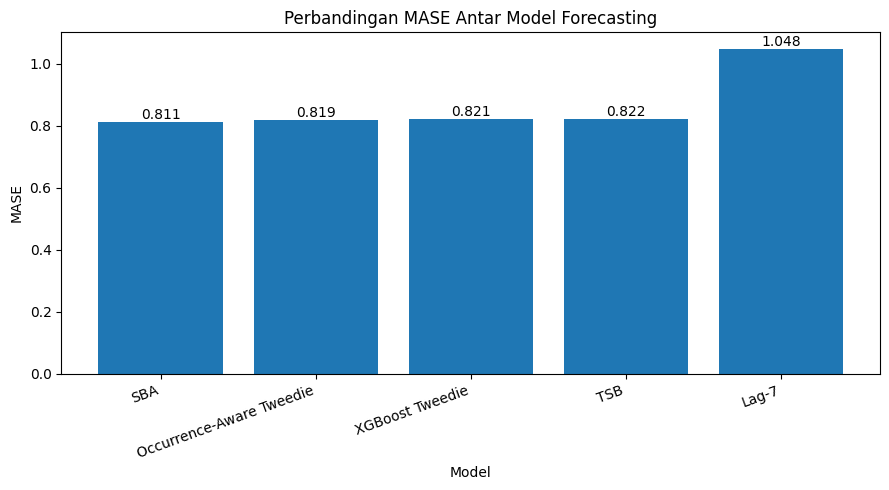

In [24]:
plot_df = (
    leaderboard
    .sort_values("MASE_mean")
    .copy()
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    plot_df["Model"],
    plot_df["MASE_mean"]
)

plt.title("Perbandingan MASE Antar Model Forecasting")
plt.xlabel("Model")
plt.ylabel("MASE")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, plot_df["MASE_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "../models/gambar_1_perbandingan_mase.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

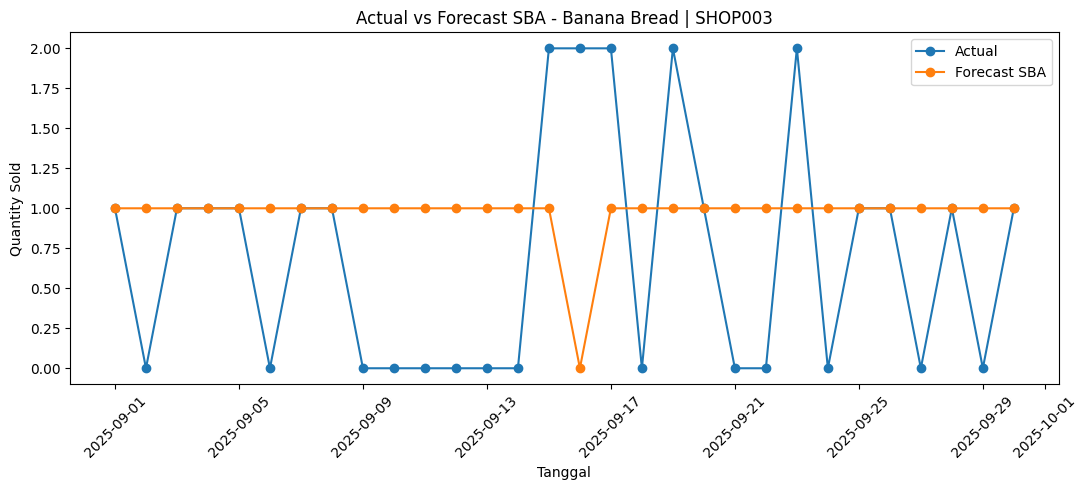

In [25]:
series_error = (
    sba_sep
    .groupby(
        ["Outlet", "ProductId", "ProductName"]
    )
    .agg(
        MAE=("AbsoluteError", "mean")
    )
    .reset_index()
    .sort_values("MAE")
    .reset_index(drop=True)
)

median_row = series_error.iloc[
    len(series_error) // 2
]

selected = sba_sep[
    (sba_sep["Outlet"] == median_row["Outlet"]) &
    (sba_sep["ProductId"] == median_row["ProductId"])
].sort_values("Date")

plt.figure(figsize=(11, 5))

plt.plot(
    selected["Date"],
    selected[TARGET],
    marker="o",
    label="Actual"
)

plt.plot(
    selected["Date"],
    selected["Prediction"],
    marker="o",
    label="Forecast SBA"
)

plt.title(
    f'Actual vs Forecast SBA - '
    f'{median_row["ProductName"]} | '
    f'{median_row["Outlet"]}'
)

plt.xlabel("Tanggal")
plt.ylabel("Quantity Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../models/gambar_2_actual_vs_forecast_september.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

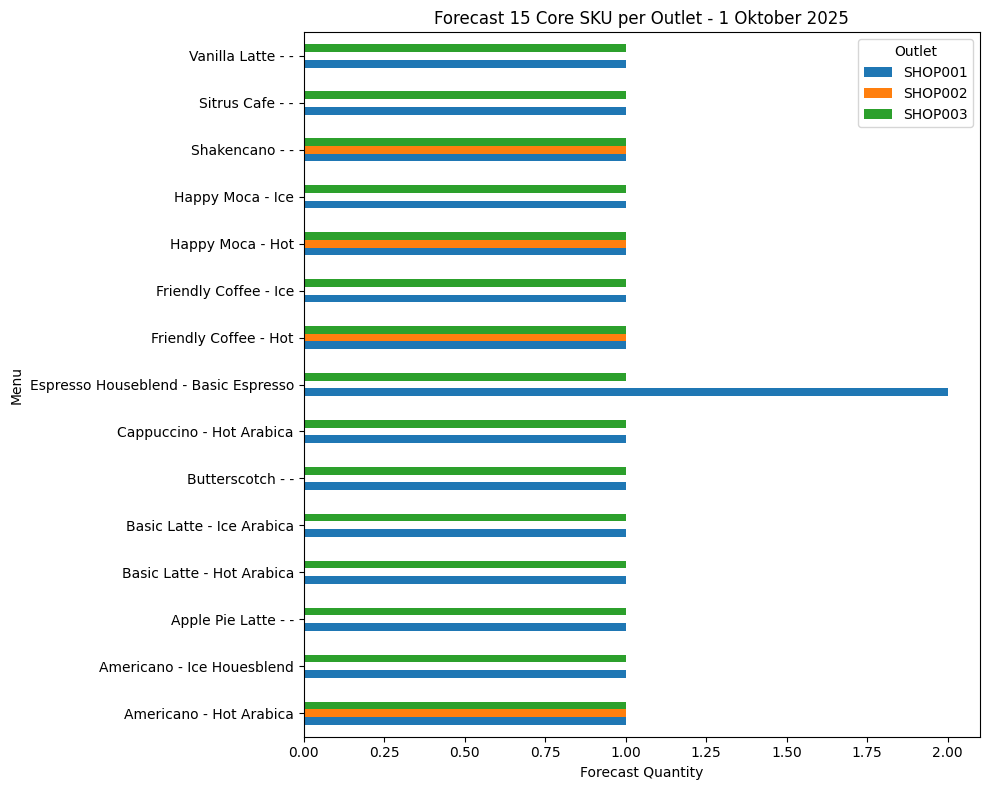

In [26]:
core_forecast_oct1["MenuLabel"] = (
    core_forecast_oct1["ProductName"].astype(str)
    + " - "
    + core_forecast_oct1["Variant"].astype(str)
)

forecast_plot = (
    core_forecast_oct1
    .pivot_table(
        index="MenuLabel",
        columns="Outlet",
        values="ForecastQuantity",
        fill_value=0
    )
)

forecast_plot = forecast_plot[
    ["SHOP001", "SHOP002", "SHOP003"]
]

forecast_plot.plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title(
    "Forecast 15 Core SKU per Outlet - 1 Oktober 2025"
)
plt.xlabel("Forecast Quantity")
plt.ylabel("Menu")
plt.legend(title="Outlet")

plt.tight_layout()

plt.savefig(
    "../models/gambar_3_forecast_15_sku_per_outlet.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()